# Player Discipline

## Research Question

Do defenders and midfielders differ significantly in their average number of yellow cards during the FIFA World Cup 2026?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
player_file = r"C:\Users\Sujan\Desktop\Fifa-World-Cup-2026\data\raw\fbref_player_stats_2026_raw.csv"

In [4]:
players = pd.read_csv(player_file, header=1)

In [5]:
players.shape

(1039, 26)

In [6]:
players[['Player', 'Pos', 'Squad', 'MP', 'Min', 'CrdY']].head(10)

,Player,Pos,Squad,MP,Min,CrdY
0,Brenden Aaronson,MF,us USA,1,76,0
1,Thelo Aasgaard,MF,no Norway,1,90,0
2,Hamza Abdelkarim,FW,eg Egypt,4,60,0
3,Hossam Abdelmaguid,DF,eg Egypt,2,59,0
4,Mohamed Abdelmonem,DF,eg Egypt,2,14,0
5,Ali Abdi,DF,tn Tunisia,3,269,0
6,Saud Abdulhamid,DF,sa Saudi Arabia,3,269,1
7,Abdulla Abdullaev,DF,uz Uzbekistan,2,180,0
8,Yusuf Abdurisag,FW,qa Qatar,2,98,0
9,Husam Abu Dahab,DF,jo Jordan,2,178,1


In [7]:
players['Pos'].value_counts()

Pos
MF      344
DF      306
FW      159
FWMF     77
GK       62
DFMF     40
MFFW     36
MFDF     12
DFFW      3
Name: count, dtype: int64

In [8]:
players[['Player', 'Pos', 'Squad', 'MP', 'Min', 'CrdY']].isnull().sum()

Player    0
Pos       0
Squad     0
MP        0
Min       0
CrdY      0
dtype: int64

In [9]:
discipline = players[
    ['Player', 'Pos', 'Squad', 'MP', 'Min', 'CrdY']
].copy()

print("Discipline dataset created.")
print("Rows:", len(discipline))

Discipline dataset created.
Rows: 1039


In [10]:
discipline = discipline[
    discipline['Pos'].isin(['DF', 'MF'])
].copy()

print("Eligible players:", len(discipline))
print("\nPosition counts:")
print(discipline['Pos'].value_counts())

Eligible players: 650

Position counts:
Pos
MF    344
DF    306
Name: count, dtype: int64


In [11]:
discipline['Position_Group'] = discipline['Pos'].map({
    'DF': 'Defender',
    'MF': 'Midfielder'
})

In [12]:
discipline[['Player', 'Pos', 'Position_Group', 'CrdY']].head(10)

,Player,Pos,Position_Group,CrdY
0,Brenden Aaronson,MF,Midfielder,0
1,Thelo Aasgaard,MF,Midfielder,0
3,Hossam Abdelmaguid,DF,Defender,0
4,Mohamed Abdelmonem,DF,Defender,0
5,Ali Abdi,DF,Defender,0
6,Saud Abdulhamid,DF,Defender,1
7,Abdulla Abdullaev,DF,Defender,0
9,Husam Abu Dahab,DF,Defender,1
10,Mohammad Abu Hasheesh,DF,Defender,0
11,Mohannad Abu Taha,DF,Defender,1


In [13]:
# Separate the two position groups

defenders = discipline[
    discipline['Position_Group'] == 'Defender'
].copy()

midfielders = discipline[
    discipline['Position_Group'] == 'Midfielder'
].copy()


# Take a reproducible random sample from each group

defender_sample = defenders.sample(
    n=150,
    random_state=42
)

midfielder_sample = midfielders.sample(
    n=150,
    random_state=42
)


# Combine both samples

discipline_sample = pd.concat(
    [defender_sample, midfielder_sample],
    ignore_index=True
)


print("Defender sample:", len(defender_sample))
print("Midfielder sample:", len(midfielder_sample))
print("Total sample:", len(discipline_sample))

Defender sample: 150
Midfielder sample: 150
Total sample: 300


In [14]:
discipline_sample['Position_Group'].value_counts()

Position_Group
Defender      150
Midfielder    150
Name: count, dtype: int64

In [15]:
discipline_sample[
    ['Player', 'Pos', 'Position_Group', 'CrdY']
].head(10)

,Player,Pos,Position_Group,CrdY
0,Brandon Mechele,DF,Defender,1
1,Ladislav Krejčí,DF,Defender,1
2,Grant Hanley,DF,Defender,0
3,Abdallah Nasib,DF,Defender,0
4,Pau Cubarsí,DF,Defender,1
5,Ricardo Adé,DF,Defender,0
6,Jack Hendry,DF,Defender,0
7,Ali Lajami,DF,Defender,0
8,Gabriel Magalhães,DF,Defender,0
9,Rafik Belghali,DF,Defender,0


In [16]:
discipline_sample['CrdY'].describe()

count    300.000000
mean       0.343333
std        0.577263
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        3.000000
Name: CrdY, dtype: float64

In [17]:
# Descriptive statistics for each position group

discipline_summary = discipline_sample.groupby(
    'Position_Group'
)['CrdY'].agg(
    Count='count',
    Mean='mean',
    Median='median',
    Standard_Deviation='std',
    Minimum='min',
    Maximum='max'
)

discipline_summary

,Count,Mean,Median,Standard_Deviation,Minimum,Maximum
Position_Group,,,,,,
Defender,150,0.346667,0.0,0.579130,0,3
Midfielder,150,0.340000,0.0,0.577312,0,2


In [18]:
# Yellow-card distribution by position group

yellow_card_distribution = pd.crosstab(
    discipline_sample['Position_Group'],
    discipline_sample['CrdY']
)

yellow_card_distribution

CrdY,0,1,2,3
Position_Group,,,,
Defender,105,39,5,1
Midfielder,107,35,8,0


In [19]:
# Percentage of players receiving at least one yellow card

yellow_card_rate = discipline_sample.groupby(
    'Position_Group'
)['CrdY'].apply(
    lambda x: (x > 0).mean() * 100
)

yellow_card_rate

Position_Group
Defender      30.000000
Midfielder    28.666667
Name: CrdY, dtype: float64

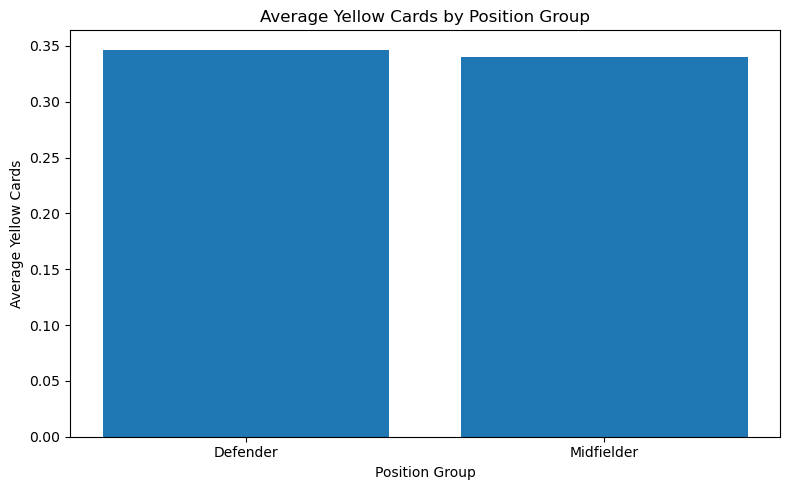

In [20]:
# Compare average yellow cards between defenders and midfielders

group_means = discipline_sample.groupby(
    'Position_Group'
)['CrdY'].mean()

plt.figure(figsize=(8, 5))

plt.bar(
    group_means.index,
    group_means.values
)

plt.title('Average Yellow Cards by Position Group')
plt.xlabel('Position Group')
plt.ylabel('Average Yellow Cards')

plt.tight_layout()
plt.show()

In [28]:
# Data-quality and assumption checks

print("DATA-QUALITY CHECK")
print("------------------")

# 1. Check sample sizes
print("Defender sample size:", len(defender_sample))
print("Midfielder sample size:", len(midfielder_sample))

# 2. Check missing values
print("\nMissing yellow-card values:")
print("Defenders:", defender_sample['CrdY'].isna().sum())
print("Midfielders:", midfielder_sample['CrdY'].isna().sum())

# 3. Check data type
print("\nYellow-card data type:")
print(discipline_sample['CrdY'].dtype)

# 4. Check possible negative values
print("\nNegative yellow-card values:")
print((discipline_sample['CrdY'] < 0).sum())

# 5. Check unique values
print("\nUnique yellow-card values:")
print(sorted(discipline_sample['CrdY'].unique()))

# 6. Check duplicate player records
print("\nDuplicate player records:")
print(discipline_sample['Player'].duplicated().sum())

DATA-QUALITY CHECK
------------------
Defender sample size: 150
Midfielder sample size: 150

Missing yellow-card values:
Defenders: 0
Midfielders: 0

Yellow-card data type:
int64

Negative yellow-card values:
0

Unique yellow-card values:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Duplicate player records:
0


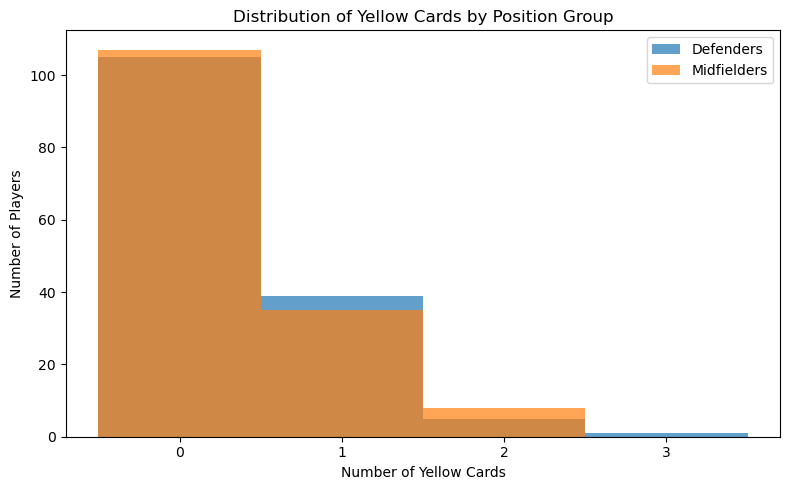

In [29]:
# Distribution of yellow cards by position group

plt.figure(figsize=(8, 5))

plt.hist(
    defender_sample['CrdY'],
    bins=np.arange(-0.5, 4.5, 1),
    alpha=0.7,
    label='Defenders'
)

plt.hist(
    midfielder_sample['CrdY'],
    bins=np.arange(-0.5, 4.5, 1),
    alpha=0.7,
    label='Midfielders'
)

plt.xticks([0, 1, 2, 3])
plt.xlabel('Number of Yellow Cards')
plt.ylabel('Number of Players')
plt.title('Distribution of Yellow Cards by Position Group')
plt.legend()

plt.tight_layout()
plt.show()

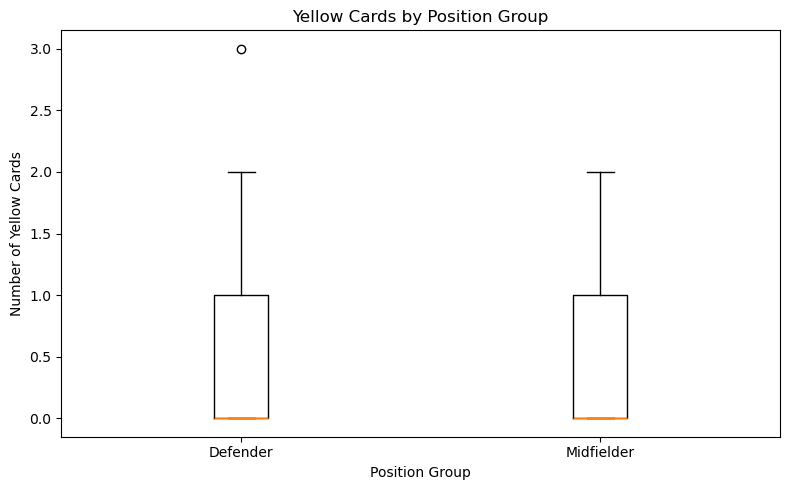

In [31]:
# Boxplot for yellow-card distribution

plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        defender_sample['CrdY'],
        midfielder_sample['CrdY']
    ],
    tick_labels=['Defender', 'Midfielder']
)

plt.xlabel('Position Group')
plt.ylabel('Number of Yellow Cards')
plt.title('Yellow Cards by Position Group')

plt.tight_layout()
plt.show()

In [21]:
# Function to calculate a 95% confidence interval for a mean

def confidence_interval(data, confidence=0.95):
    n = len(data)
    mean = data.mean()
    standard_error = stats.sem(data)
    
    margin_of_error = stats.t.ppf(
        (1 + confidence) / 2,
        n - 1
    ) * standard_error
    
    lower = mean - margin_of_error
    upper = mean + margin_of_error
    
    return lower, upper


# Calculate confidence intervals

defender_ci = confidence_interval(
    defender_sample['CrdY']
)

midfielder_ci = confidence_interval(
    midfielder_sample['CrdY']
)


print("Defender 95% CI:", defender_ci)
print("Midfielder 95% CI:", midfielder_ci)

Defender 95% CI: (np.float64(0.2532293770450085), np.float64(0.4401039562883249))
Midfielder 95% CI: (np.float64(0.24685609738796388), np.float64(0.43314390261203617))


In [22]:
# Create a confidence interval summary table

ci_summary = pd.DataFrame({
    'Position_Group': [
        'Defender',
        'Midfielder'
    ],
    'Mean': [
        defender_sample['CrdY'].mean(),
        midfielder_sample['CrdY'].mean()
    ],
    'CI_Lower': [
        defender_ci[0],
        midfielder_ci[0]
    ],
    'CI_Upper': [
        defender_ci[1],
        midfielder_ci[1]
    ]
})

ci_summary

,Position_Group,Mean,CI_Lower,CI_Upper
0,Defender,0.346667,0.253229,0.440104
1,Midfielder,0.340000,0.246856,0.433144


In [23]:
# Independent two-sample Welch t-test

defender_yellow_cards = defender_sample['CrdY']
midfielder_yellow_cards = midfielder_sample['CrdY']

t_statistic, p_value = stats.ttest_ind(
    defender_yellow_cards,
    midfielder_yellow_cards,
    equal_var=False
)

print("Welch Two-Sample t-Test")
print("-----------------------")
print("t-statistic:", t_statistic)
print("p-value:", p_value)

Welch Two-Sample t-Test
-----------------------
t-statistic: 0.09984933447541
p-value: 0.9205310791171409


In [24]:
# Statistical decision

alpha = 0.05

if p_value < alpha:
    print("Reject H0")
    print("There is a statistically significant difference between defenders and midfielders.")
else:
    print("Fail to reject H0")
    print("There is no statistically significant difference between defenders and midfielders.")

Fail to reject H0
There is no statistically significant difference between defenders and midfielders.


In [25]:
# Calculate the difference in mean yellow cards

defender_mean = defender_sample['CrdY'].mean()
midfielder_mean = midfielder_sample['CrdY'].mean()

mean_difference = defender_mean - midfielder_mean

print("Defender mean:", round(defender_mean, 4))
print("Midfielder mean:", round(midfielder_mean, 4))
print("Mean difference:", round(mean_difference, 4))

Defender mean: 0.3467
Midfielder mean: 0.34
Mean difference: 0.0067


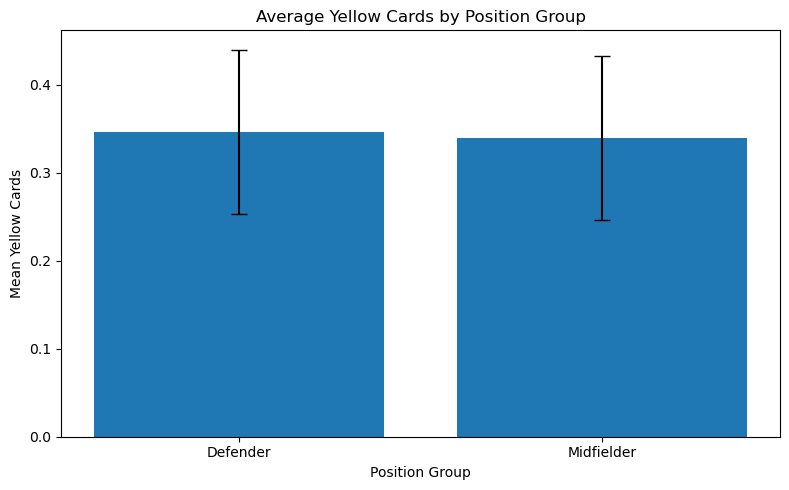

In [26]:
# Prepare data for the final visualisation

groups = ['Defender', 'Midfielder']

means = [
    defender_sample['CrdY'].mean(),
    midfielder_sample['CrdY'].mean()
]

lower_bounds = [
    defender_ci[0],
    midfielder_ci[0]
]

upper_bounds = [
    defender_ci[1],
    midfielder_ci[1]
]

# Calculate error-bar sizes

lower_errors = [
    means[i] - lower_bounds[i]
    for i in range(2)
]

upper_errors = [
    upper_bounds[i] - means[i]
    for i in range(2)
]

# Create the chart

plt.figure(figsize=(8, 5))

plt.bar(
    groups,
    means,
    yerr=[lower_errors, upper_errors],
    capsize=6
)

plt.title('Average Yellow Cards by Position Group')
plt.xlabel('Position Group')
plt.ylabel('Mean Yellow Cards')

plt.tight_layout()
plt.show()

In [27]:
# Final statistical results table

final_results = pd.DataFrame({
    'Position Group': ['Defender', 'Midfielder'],
    'Sample Size': [150, 150],
    'Mean Yellow Cards': [
        defender_mean,
        midfielder_mean
    ],
    'Median': [
        defender_sample['CrdY'].median(),
        midfielder_sample['CrdY'].median()
    ],
    'Standard Deviation': [
        defender_sample['CrdY'].std(),
        midfielder_sample['CrdY'].std()
    ],
    '95% CI Lower': [
        defender_ci[0],
        midfielder_ci[0]
    ],
    '95% CI Upper': [
        defender_ci[1],
        midfielder_ci[1]
    ]
})

final_results.round(4)

,Position Group,Sample Size,Mean Yellow Cards,Median,Standard Deviation,95% CI Lower,95% CI Upper
0,Defender,150,0.3467,0.0,0.5791,0.2532,0.4401
1,Midfielder,150,0.3400,0.0,0.5773,0.2469,0.4331


## Hypothesis Test Result

In [33]:
# Display the hypothesis test result

print("Welch Two-Sample t-Test")
print("-----------------------")
print(f"t-statistic = {t_statistic:.5f}")
print(f"p-value = {p_value:.5f}")
print(f"Significance level (α) = {alpha}")

if p_value < alpha:
    print("\nDecision: Reject H₀")
else:
    print("\nDecision: Fail to reject H₀")

Welch Two-Sample t-Test
-----------------------
t-statistic = 0.09985
p-value = 0.92053
Significance level (α) = 0.05

Decision: Fail to reject H₀


In [34]:
# Save the final analysis sample

discipline_sample.to_csv(
    'task2_player_discipline_sample.csv',
    index=False
)

print("Saved: task2_player_discipline_sample.csv")

Saved: task2_player_discipline_sample.csv


In [35]:
# Verify the processed dataset

saved_sample = pd.read_csv(
    'task2_player_discipline_sample.csv'
)

print("Rows:", saved_sample.shape[0])
print("Columns:", saved_sample.shape[1])

display(saved_sample.head())

Rows: 300
Columns: 7


,Player,Pos,Squad,MP,Min,CrdY,Position_Group
0,Brandon Mechele,DF,be Belgium,6,570,1,Defender
1,Ladislav Krejčí,DF,cz Czechia,3,270,1,Defender
2,Grant Hanley,DF,sct Scotland,2,180,0,Defender
3,Abdallah Nasib,DF,jo Jordan,3,260,0,Defender
4,Pau Cubarsí,DF,es Spain,8,750,1,Defender
